Sequential Chats and Customer Onboarding

## Setup

In [1]:
llm_config = {"model": "llama3","api_type":"ollama"}

In [2]:
from autogen import ConversableAgent

## Creating the needed agents

In [3]:
onboarding_personal_information_agent = ConversableAgent(
    name="onboarding_personal_information_agent",  # Removed spaces
    system_message='''You are a helpful customer onboarding agent.
    You are here to help new customers get started with our product.
    Your job is to gather customer's name and location.
    Do not ask for other information. Return 'TERMINATE' 
    when you have gathered all the information.''',
    llm_config=llm_config,
    code_execution_config=False,
    human_input_mode="NEVER",
)

onboarding_topic_preference_agent = ConversableAgent(
    name="onboarding_topic_preference_agent",  # Removed spaces
    system_message='''You are a helpful customer onboarding agent.
    You are here to help new customers get started with our product.
    Your job is to gather customer's preferences on news topics.
    Do not ask for other information.
    Return 'TERMINATE' when you have gathered all the information.''',
    llm_config=llm_config,
    code_execution_config=False,
    human_input_mode="NEVER",
)

customer_engagement_agent = ConversableAgent(
    name="customer_engagement_agent",  # Removed spaces
    system_message='''You are a helpful customer service agent.
    You are here to provide fun for the customer based on the user's
    personal information and topic preferences.
    This could include fun facts, jokes, or interesting stories.
    Make sure to make it engaging and fun!
    Return 'TERMINATE' when you are done.''',
    llm_config=llm_config,
    code_execution_config=False,
    human_input_mode="NEVER",
    is_termination_msg=lambda msg: "terminate" in msg.get("content").lower(),
)

customer_proxy_agent = ConversableAgent(
    name="customer_proxy_agent",
    llm_config=False,
    code_execution_config=False,
    human_input_mode="ALWAYS",
    is_termination_msg=lambda msg: "terminate" in msg.get("content").lower(),
)

## Creating tasks

Now, you can craft a series of tasks to facilitate the onboarding process.

In [4]:
chats = [
    {
        "sender": onboarding_personal_information_agent,
        "recipient": customer_proxy_agent,
        "message": "Hello, I'm here to help you get started with our product. Could you tell me your name and location?",
        "summary_method": "reflection_with_llm",
        "summary_args": {
            "summary_prompt": "Return the customer information as JSON object only: {'name': '', 'location': ''}",
        },
        "max_turns": 1,
        "clear_history": True
    },
    {
        "sender": onboarding_topic_preference_agent,
        "recipient": customer_proxy_agent,
        "message": "Great! Could you tell me what topics you are interested in reading about?",
        "summary_method": "reflection_with_llm",
        "max_turns": 1,
        "clear_history": False
    },
    {
        "sender": customer_proxy_agent,
        "recipient": customer_engagement_agent,
        "message": "Let's find something fun to read.",
        "max_turns": 1,
        "summary_method": "reflection_with_llm",
    },
]

## Start the onboarding process

**Note**: You might get a slightly different response than what's shown in the video. Feel free to try different inputs, such as name, location, and preferences.

In [5]:
from autogen import initiate_chats

chat_results = initiate_chats(chats)


********************************************************************************
Starting a new chat....

********************************************************************************
onboarding_personal_information_agent (to customer_proxy_agent):

Hello, I'm here to help you get started with our product. Could you tell me your name and location?

--------------------------------------------------------------------------------


c:\Users\Paul\anaconda3\envs\cuda_gpu\Lib\site-packages\autogen\agentchat\chat.py:69: UserWarning: Repetitive recipients detected: The chat history will be cleared by default if a recipient appears more than once. To retain the chat history, please set 'clear_history=False' in the configuration of the repeating agent.
  warnings.warn(


customer_proxy_agent (to onboarding_personal_information_agent):

My name is Paul Immanuel and I am from India

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (e86312a7-8295-4072-998c-acac867d4984): Maximum turns (1) reached

********************************************************************************
Starting a new chat....

********************************************************************************
onboarding_topic_preference_agent (to customer_proxy_agent):

Great! Could you tell me what topics you are interested in reading about?
Context: 
{'name': 'Paul Immanuel', 'location': 'India'}

--------------------------------------------------------------------------------
customer_proxy_agent (to onboarding_topic_preference_agent):

Interested in latest Tech stack news

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (09fee6c3-39fd-4c5b-8705-d39e374e3d06): Maxim

## Print out the summary

In [6]:
summary=[]
for chat_result in chat_results:
    print(chat_result.summary)
    summary.append(chat_result.summary)
    print("\n")

{'name': 'Paul Immanuel', 'location': 'India'}


I'm interested in latest Tech stack news.


Cloud-native applications are gaining popularity with 70% of organizations planning to move at least half their apps to the cloud within two years. India is home to incredible tech talent, and Indian startups like Ola Electric are revolutionizing the e-mobility space.




In [7]:
summary[0]

"{'name': 'Paul Immanuel', 'location': 'India'}"

In [8]:
#!pip install pandas

In [9]:
import pandas as pd
import ast

# Input string
#data_str = "{'name': 'Ramisha', 'location': 'Coimbatore'}"
data_str=summary[0]
# Convert string to dictionary
data_dict = ast.literal_eval(data_str)

# Convert dictionary to DataFrame
df = pd.DataFrame([data_dict])

df


,name,location
0,Paul Immanuel,India


In [10]:
df["TopicPreference"]=summary[1]

In [11]:
df

,name,location,TopicPreference
0,Paul Immanuel,India,I'm interested in latest Tech stack news.


In [12]:
df["Enagement"]=summary[2]

In [13]:
df

,name,location,TopicPreference,Enagement
0,Paul Immanuel,India,I'm interested in latest Tech stack news.,Cloud-native applications are gaining populari...


In [14]:
#!pip install gspread
#!pip install oauth2client

In [17]:
def add_leads_to_google_sheet(df):
    import gspread
    from oauth2client.service_account import ServiceAccountCredentials

    # Define the scope for Google Sheets API
    scope = ['https://www.googleapis.com/auth/spreadsheets']

    # Add credentials to the account
    creds = ServiceAccountCredentials.from_json_keyfile_name(
        'my-project-378715-d6b72c900fc4.json', scope
    )

    # Authorize the client
    client = gspread.authorize(creds)

    # Specify the Google Sheet ID
    sheet_id = '1QWXIymVxGKzmaLs7S2H6mc-FHA_3W5YB1tnW_iT_mYg'

    # Open the spreadsheet using its ID
    spreadsheet = client.open_by_key(sheet_id)

    # Select the first worksheet (index 0)
    worksheet = spreadsheet.get_worksheet(0)

    # Append each row of the DataFrame to the worksheet
    for _, row in df.iterrows():
        # Convert row to a list and append to the sheet
        worksheet.append_row(row.tolist())

    print("Data added successfully!")
    return "added"


In [18]:
add_leads_to_google_sheet(df)

Data added successfully!


'added'

## Print out the cost

In [19]:
for chat_result in chat_results:
    print(chat_result.cost)
    print("\n")

{'usage_including_cached_inference': {'total_cost': 0.0, 'llama3': {'cost': 0.0, 'prompt_tokens': 72, 'completion_tokens': 15, 'total_tokens': 87}}, 'usage_excluding_cached_inference': {'total_cost': 0.0, 'llama3': {'cost': 0.0, 'prompt_tokens': 72, 'completion_tokens': 15, 'total_tokens': 87}}}


{'usage_including_cached_inference': {'total_cost': 0.0, 'llama3': {'cost': 0.0, 'prompt_tokens': 74, 'completion_tokens': 10, 'total_tokens': 84}}, 'usage_excluding_cached_inference': {'total_cost': 0.0, 'llama3': {'cost': 0.0, 'prompt_tokens': 74, 'completion_tokens': 10, 'total_tokens': 84}}}


{'usage_including_cached_inference': {'total_cost': 0.0, 'llama3': {'cost': 0.0, 'prompt_tokens': 436, 'completion_tokens': 305, 'total_tokens': 741}}, 'usage_excluding_cached_inference': {'total_cost': 0.0, 'llama3': {'cost': 0.0, 'prompt_tokens': 436, 'completion_tokens': 305, 'total_tokens': 741}}}




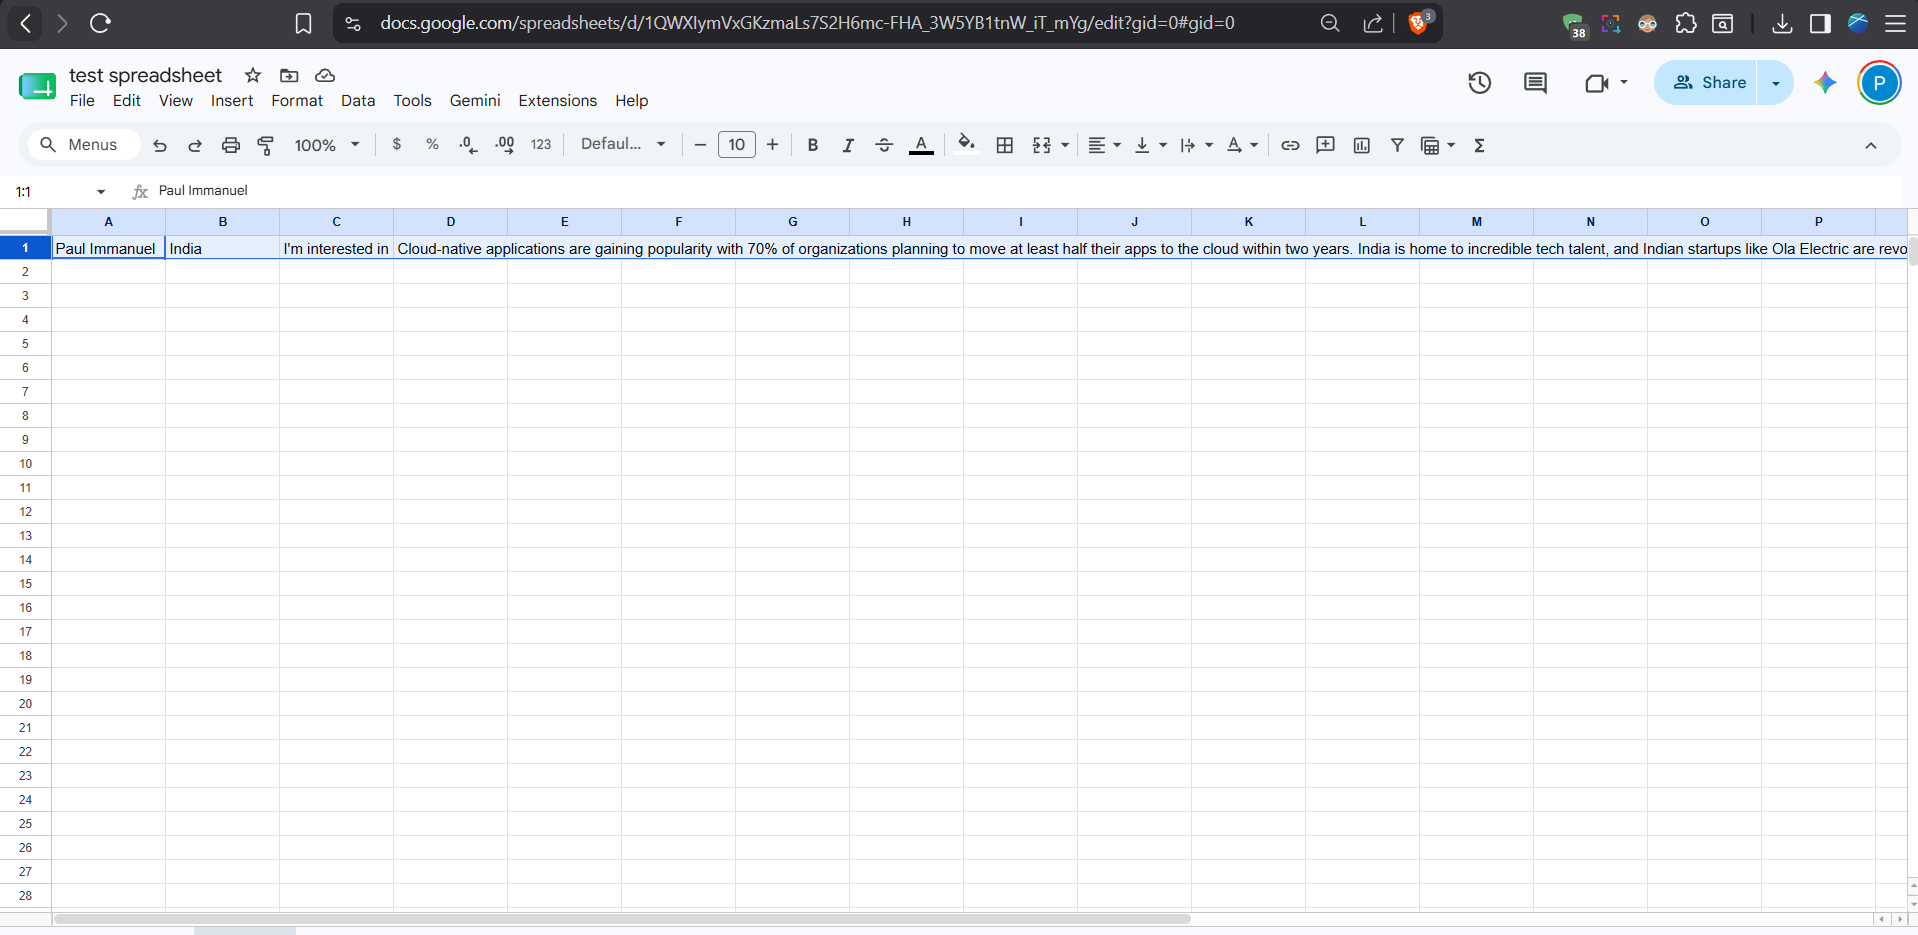

In [ ]:
from IPython.display import Image, display
display(Image(filename='Google Spreadsheets Ollama Output.png'))
